In [2]:
import json
from collections import Counter
from pathlib import Path

def analyze_malaria_dataset(train_json: str, test_json: str):
    """
    Analyse le dataset de paludisme et compte les annotations par classe.
    
    Args:
        train_json: Chemin vers training.json
        test_json: Chemin vers test.json
    """
    
    print("="*80)
    print("📊 ANALYSE DU DATASET PALUDISME (Falciparum)")
    print("="*80)
    
    # Charger les fichiers JSON
    with open(train_json, 'r') as f:
        train_data = json.load(f)
    
    with open(test_json, 'r') as f:
        test_data = json.load(f)
    
    print(f"\n✓ Training set: {len(train_data)} images chargées")
    print(f"✓ Test set:     {len(test_data)} images chargées")
    print(f"✓ Total:        {len(train_data) + len(test_data)} images")
    
    # Fonction pour compter les catégories
    def count_categories(data, split_name):
        category_counter = Counter()
        total_objects = 0
        images_with_objects = 0
        
        for item in data:
            objects = item.get('objects', [])
            if len(objects) > 0:
                images_with_objects += 1
            
            for obj in objects:
                category = obj.get('category', 'unknown')
                category_counter[category] += 1
                total_objects += 1
        
        return category_counter, total_objects, images_with_objects
    
    # Analyser train
    train_categories, train_total, train_with_obj = count_categories(train_data, "Training")
    
    # Analyser test
    test_categories, test_total, test_with_obj = count_categories(test_data, "Test")
    
    # Combiner
    all_categories = train_categories + test_categories
    
    # Afficher résultats
    print("\n" + "="*80)
    print("📋 DISTRIBUTION DES CLASSES")
    print("="*80)
    
    print(f"\n{'Classe':<40} {'Train':<12} {'Test':<12} {'Total':<12} {'%':<8}")
    print("-"*80)
    
    for category, total_count in all_categories.most_common():
        train_count = train_categories[category]
        test_count = test_categories[category]
        percentage = (total_count / (train_total + test_total)) * 100
        
        print(f"{category:<40} {train_count:<12} {test_count:<12} {total_count:<12} {percentage:>6.2f}%")
    
    # Résumé
    print("\n" + "="*80)
    print("📊 RÉSUMÉ")
    print("="*80)
    
    print(f"\nNombre de classes uniques: {len(all_categories)}")
    print(f"\nAnnotations totales:")
    print(f"  - Training: {train_total} annotations dans {train_with_obj}/{len(train_data)} images")
    print(f"  - Test:     {test_total} annotations dans {test_with_obj}/{len(test_data)} images")
    print(f"  - Total:    {train_total + test_total} annotations")
    
    print(f"\nMoyenne par image:")
    print(f"  - Training: {train_total/len(train_data):.1f} objets/image")
    print(f"  - Test:     {test_total/len(test_data):.1f} objets/image")
    
    # Images vides
    train_empty = len(train_data) - train_with_obj
    test_empty = len(test_data) - test_with_obj
    
    print(f"\nImages sans annotations:")
    print(f"  - Training: {train_empty}/{len(train_data)} ({train_empty/len(train_data)*100:.1f}%)")
    print(f"  - Test:     {test_empty}/{len(test_data)} ({test_empty/len(test_data)*100:.1f}%)")
    
    # Classe majoritaire vs minoritaire
    most_common = all_categories.most_common(1)[0]
    least_common = all_categories.most_common()[-1]
    
    print(f"\nClasse majoritaire:  {most_common[0]} ({most_common[1]} annotations)")
    print(f"Classe minoritaire:  {least_common[0]} ({least_common[1]} annotations)")
    
    ratio = most_common[1] / least_common[1] if least_common[1] > 0 else 0
    print(f"Ratio déséquilibre:  {ratio:.1f}:1")
    
    print("\n" + "="*80)
    
    return {
        'train_categories': train_categories,
        'test_categories': test_categories,
        'all_categories': all_categories,
        'total_classes': len(all_categories),
        'total_annotations': train_total + test_total
    }


# ==================== UTILISATION ====================

if __name__ == "__main__":
    # Chemins vers tes fichiers
    TRAIN_JSON = "training.json"
    TEST_JSON = "test.json"
    
    # Analyser
    results = analyze_malaria_dataset(TRAIN_JSON, TEST_JSON)
    
    # Liste complète des classes
    print("\n📋 LISTE COMPLÈTE DES CLASSES:")
    print("-" * 40)
    for i, category in enumerate(results['all_categories'].keys(), 1):
        count = results['all_categories'][category]
        print(f"{i:2d}. {category} ({count} annotations)")

📊 ANALYSE DU DATASET PALUDISME (Falciparum)

✓ Training set: 1208 images chargées
✓ Test set:     120 images chargées
✓ Total:        1328 images

📋 DISTRIBUTION DES CLASSES

Classe                                   Train        Test         Total        %       
--------------------------------------------------------------------------------
red blood cell                           77420        5614         83034         96.51%
trophozoite                              1473         111          1584           1.84%
ring                                     353          169          522            0.61%
difficult                                441          5            446            0.52%
schizont                                 179          11           190            0.22%
gametocyte                               144          12           156            0.18%
leukocyte                                103          0            103            0.12%

📊 RÉSUMÉ

Nombre de classes uniques: 7

In [7]:
import json
import random
import numpy as np
from pathlib import Path
from PIL import Image
import math
from typing import List, Dict, Tuple
from collections import Counter

class MalariaPatcher:
    """
    Patcher pour le dataset de paludisme - ULTRA-RADICAL pour égaliser RBC.
    """
    
    def __init__(
        self,
        images_dir: str,
        train_json: str,
        test_json: str,
        output_dir: str,
        patch_size: int = 1024,
        overlap: int = 128
    ):
        self.images_dir = Path(images_dir)
        self.train_json = Path(train_json)
        self.test_json = Path(test_json)
        self.output_dir = Path(output_dir)
        self.patch_size = patch_size
        self.overlap = overlap
        
        self.patches_dir = self.output_dir / "patches"
        self.patches_dir.mkdir(parents=True, exist_ok=True)
        
        self.KEEP_CLASSES = {
            'red blood cell',
            'trophozoite',
            'ring',
            'schizont',
            'gametocyte'
        }
        
        self.PARASITE_CLASSES = {
            'trophozoite',
            'ring',
            'schizont',
            'gametocyte'
        }
        
        print("🔬 MALARIA PATCHER - STRATÉGIE ULTRA-RADICALE 🔥")
        print("="*60)
        print(f"Objectif: Égaliser RBC avec parasites (~3000 chaque)")
        print("="*60)
    
    def load_and_merge_data(self, train_images: int = 1000):
        print("\n📂 Chargement des données...")
        
        with open(self.train_json, 'r') as f:
            train_data = json.load(f)
        with open(self.test_json, 'r') as f:
            test_data = json.load(f)
        
        all_data = train_data + test_data
        print(f"✓ Total images: {len(all_data)}")
        
        random.seed(42)
        random.shuffle(all_data)
        
        new_train = all_data[:train_images]
        new_test = all_data[train_images:]
        
        print(f"✓ Nouveau split:")
        print(f"  - Train: {len(new_train)} images")
        print(f"  - Test:  {len(new_test)} images")
        
        return new_train, new_test
    
    def calculate_patches(self, width: int, height: int) -> List[Tuple[int, int, int, int]]:
        patches = []
        stride = self.patch_size - self.overlap
        
        n_patches_x = math.ceil((width - self.overlap) / stride)
        n_patches_y = math.ceil((height - self.overlap) / stride)
        
        for i in range(n_patches_y):
            for j in range(n_patches_x):
                x1 = j * stride
                y1 = i * stride
                x2 = min(x1 + self.patch_size, width)
                y2 = min(y1 + self.patch_size, height)
                
                if x2 - x1 < self.patch_size and x2 == width:
                    x1 = max(0, width - self.patch_size)
                if y2 - y1 < self.patch_size and y2 == height:
                    y1 = max(0, height - self.patch_size)
                
                patches.append((x1, y1, x2, y2))
        
        return patches
    
    def bbox_intersects_patch(
        self,
        bbox: Dict,
        patch_coords: Tuple[int, int, int, int],
        min_overlap_ratio: float = 0.5
    ) -> bool:
        x1_patch, y1_patch, x2_patch, y2_patch = patch_coords
        
        x1_obj = bbox['minimum']['c']
        y1_obj = bbox['minimum']['r']
        x2_obj = bbox['maximum']['c']
        y2_obj = bbox['maximum']['r']
        
        x1_inter = max(x1_patch, x1_obj)
        y1_inter = max(y1_patch, y1_obj)
        x2_inter = min(x2_patch, x2_obj)
        y2_inter = min(y2_patch, y2_obj)
        
        if x1_inter >= x2_inter or y1_inter >= y2_inter:
            return False
        
        intersection_area = (x2_inter - x1_inter) * (y2_inter - y1_inter)
        object_area = (x2_obj - x1_obj) * (y2_obj - y1_obj)
        overlap_ratio = intersection_area / object_area if object_area > 0 else 0
        
        return overlap_ratio >= min_overlap_ratio
    
    def adjust_bbox_to_patch(
        self,
        bbox: Dict,
        patch_coords: Tuple[int, int, int, int]
    ) -> Dict:
        x1_patch, y1_patch, x2_patch, y2_patch = patch_coords
        
        x1_obj = bbox['minimum']['c']
        y1_obj = bbox['minimum']['r']
        x2_obj = bbox['maximum']['c']
        y2_obj = bbox['maximum']['r']
        
        new_x1 = max(0, x1_obj - x1_patch)
        new_y1 = max(0, y1_obj - y1_patch)
        new_x2 = min(x2_obj - x1_patch, x2_patch - x1_patch)
        new_y2 = min(y2_obj - y1_patch, y2_patch - y1_patch)
        
        return {
            'minimum': {'r': int(new_y1), 'c': int(new_x1)},
            'maximum': {'r': int(new_y2), 'c': int(new_x2)}
        }
    
    def sample_red_blood_cells(
        self,
        objects: List[Dict],
        rbcs_per_parasite: int = 1,
        max_rbcs_per_patch: int = 15
    ) -> List[Dict]:
        """
        STRATÉGIE ULTRA-RADICALE: 1 RBC par parasite + max 15 RBC par patch.
        """
        parasites = [obj for obj in objects if obj['category'] in self.PARASITE_CLASSES]
        rbcs = [obj for obj in objects if obj['category'] == 'red blood cell']
        
        if len(parasites) == 0:
            return objects
        
        # ✅ 1 RBC par parasite OU max 15 RBC
        num_rbcs_to_keep = min(
            len(parasites) * rbcs_per_parasite,
            max_rbcs_per_patch
        )
        
        if len(rbcs) <= num_rbcs_to_keep:
            return objects
        
        sampled_rbcs = random.sample(rbcs, num_rbcs_to_keep)
        
        return parasites + sampled_rbcs
    
    def process_images(
        self,
        data: List[Dict],
        split_name: str,
        min_overlap_ratio: float = 0.5,
        rbcs_per_parasite: int = 1,
        max_rbcs_per_patch: int = 15,
        rbc_only_keep_ratio: float = 0.05
    ) -> Dict:
        print(f"\n🔄 Traitement du {split_name} set - ULTRA-RADICAL 🔥")
        print("="*60)
        print(f"⚙️  RBC par parasite: {rbcs_per_parasite}")
        print(f"⚙️  Max RBC par patch: {max_rbcs_per_patch}")
        print(f"⚙️  Patches RBC-only gardés: {rbc_only_keep_ratio*100:.0f}%")
        print("="*60)
        
        new_images = []
        image_id = 0
        
        stats = {
            'total_patches': 0,
            'patches_with_parasites': 0,
            'patches_rbc_only': 0,
            'rbc_only_patches_skipped': 0,
            'class_count': Counter(),
            'class_count_before_sampling': Counter(),
            'rbcs_removed': 0
        }
        
        for img_idx, img_data in enumerate(data):
            img_path = self.images_dir / Path(img_data['image']['pathname']).name
            
            if not img_path.exists():
                continue
            
            if (img_idx + 1) % 50 == 0:
                print(f"  [{img_idx+1}/{len(data)}] {img_path.name}")
            
            image = Image.open(img_path)
            width, height = image.size
            
            patches = self.calculate_patches(width, height)
            
            original_objects = img_data.get('objects', [])
            filtered_objects = [
                obj for obj in original_objects
                if obj.get('category') in self.KEEP_CLASSES
            ]
            
            for patch_idx, (x1, y1, x2, y2) in enumerate(patches):
                patch_img = image.crop((x1, y1, x2, y2))
                
                patch_objects = []
                for obj in filtered_objects:
                    if self.bbox_intersects_patch(
                        obj['bounding_box'],
                        (x1, y1, x2, y2),
                        min_overlap_ratio
                    ):
                        adjusted_obj = {
                            'bounding_box': self.adjust_bbox_to_patch(
                                obj['bounding_box'],
                                (x1, y1, x2, y2)
                            ),
                            'category': obj['category']
                        }
                        patch_objects.append(adjusted_obj)
                
                for obj in patch_objects:
                    stats['class_count_before_sampling'][obj['category']] += 1
                
                # ✅ ULTRA-RADICAL
                rbcs_before = len([o for o in patch_objects if o['category'] == 'red blood cell'])
                patch_objects = self.sample_red_blood_cells(
                    patch_objects, 
                    rbcs_per_parasite, 
                    max_rbcs_per_patch
                )
                rbcs_after = len([o for o in patch_objects if o['category'] == 'red blood cell'])
                stats['rbcs_removed'] += (rbcs_before - rbcs_after)
                
                if len(patch_objects) == 0:
                    continue
                
                has_parasites = any(
                    obj['category'] in self.PARASITE_CLASSES
                    for obj in patch_objects
                )
                
                # ✅ Filtrer 95% des patches RBC-only
                if not has_parasites:
                    if random.random() > rbc_only_keep_ratio:
                        stats['rbc_only_patches_skipped'] += 1
                        continue
                    else:
                        stats['patches_rbc_only'] += 1
                else:
                    stats['patches_with_parasites'] += 1
                
                patch_name = f"{img_path.stem}_patch_{patch_idx:04d}.png"
                patch_path = self.patches_dir / patch_name
                
                patch_img.save(patch_path)
                
                for obj in patch_objects:
                    stats['class_count'][obj['category']] += 1
                
                new_images.append({
                    'image': {
                        'pathname': f'/patches/{patch_name}',
                        'shape': {
                            'r': patch_img.height,
                            'c': patch_img.width,
                            'channels': 3
                        }
                    },
                    'objects': patch_objects,
                    'metadata': {
                        'original_image': img_path.name,
                        'patch_index': patch_idx,
                        'patch_coords': [x1, y1, x2, y2],
                        'has_parasites': has_parasites
                    }
                })
                
                stats['total_patches'] += 1
                image_id += 1
            
            image.close()
        
        print("\n" + "="*60)
        print(f"✅ {split_name.upper()} SET - TRAITEMENT TERMINÉ")
        print("="*60)
        print(f"Patches créés: {stats['total_patches']}")
        print(f"  - Avec parasites: {stats['patches_with_parasites']} ({stats['patches_with_parasites']/stats['total_patches']*100:.1f}%)")
        print(f"  - RBC seulement: {stats['patches_rbc_only']} ({stats['patches_rbc_only']/stats['total_patches']*100:.1f}%)")
        print(f"  - RBC-only skippés: {stats['rbc_only_patches_skipped']}")
        
        print(f"\n📊 RÉÉQUILIBRAGE ULTRA-RADICAL:")
        rbcs_before = stats['class_count_before_sampling']['red blood cell']
        rbcs_after = stats['class_count']['red blood cell']
        print(f"  RBC avant: {rbcs_before}")
        print(f"  RBC après: {rbcs_after}")
        print(f"  Supprimés: {stats['rbcs_removed']} ({stats['rbcs_removed']/rbcs_before*100:.1f}%)")
        
        print(f"\n📋 DISTRIBUTION DES CLASSES:")
        total_objects = sum(stats['class_count'].values())
        for category, count in stats['class_count'].most_common():
            pct = (count / total_objects * 100) if total_objects > 0 else 0
            marker = "🦠" if category in self.PARASITE_CLASSES else "🔴"
            print(f"  {marker} {category:<20} {count:>6} ({pct:>5.1f}%)")
        
        return {
            'data': new_images,
            'stats': stats
        }
    
    def save_json(self, data: List[Dict], output_path: str):
        with open(output_path, 'w') as f:
            json.dump(data, f, indent=2)
        print(f"\n💾 Sauvegardé: {output_path}")
    
    def run(
        self,
        train_images: int = 1000,
        min_overlap_ratio: float = 0.5,
        rbcs_per_parasite: int = 1,
        max_rbcs_per_patch: int = 15,
        rbc_only_keep_ratio: float = 0.05
    ):
        train_data, test_data = self.load_and_merge_data(train_images)
        
        train_result = self.process_images(
            train_data, 'train',
            min_overlap_ratio,
            rbcs_per_parasite,
            max_rbcs_per_patch,
            rbc_only_keep_ratio
        )
        
        test_result = self.process_images(
            test_data, 'test',
            min_overlap_ratio,
            rbcs_per_parasite,
            max_rbcs_per_patch,
            rbc_only_keep_ratio
        )
        
        train_json_out = self.output_dir / "training_patches.json"
        test_json_out = self.output_dir / "test_patches.json"
        
        self.save_json(train_result['data'], train_json_out)
        self.save_json(test_result['data'], test_json_out)
        
        print("\n" + "="*60)
        print("🎯 RÉSUMÉ FINAL - ULTRA-RADICAL 🔥")
        print("="*60)
        
        total_patches = train_result['stats']['total_patches'] + test_result['stats']['total_patches']
        total_parasites = (
            train_result['stats']['patches_with_parasites'] +
            test_result['stats']['patches_with_parasites']
        )
        
        print(f"Total patches créés: {total_patches}")
        print(f"Patches avec parasites: {total_parasites} ({total_parasites/total_patches*100:.1f}%)")
        
        print(f"\n📊 DISTRIBUTION FINALE:")
        all_classes = train_result['stats']['class_count'] + test_result['stats']['class_count']
        total_obj = sum(all_classes.values())
        
        for category, count in all_classes.most_common():
            pct = (count / total_obj * 100) if total_obj > 0 else 0
            marker = "🦠" if category in self.PARASITE_CLASSES else "🔴"
            print(f"  {marker} {category:<20} {count:>6} ({pct:>5.1f}%)")
        
        rbc_count = all_classes['red blood cell']
        parasite_count = total_obj - rbc_count
        
        print(f"\n🎯 ÉQUILIBRE FINAL:")
        print(f"  RBC:       {rbc_count} ({rbc_count/total_obj*100:.1f}%)")
        print(f"  Parasites: {parasite_count} ({parasite_count/total_obj*100:.1f}%)")
        
        if rbc_count <= parasite_count * 1.2:  # Max 20% de différence
            print(f"  ✅✅✅ PARFAITEMENT ÉQUILIBRÉ!")
        elif rbc_count <= parasite_count * 1.5:
            print(f"  ✅ BIEN ÉQUILIBRÉ!")
        else:
            print(f"  ⚠️  Encore à améliorer")
        
        print(f"\n📁 Patches: {self.patches_dir}")
        print("="*60)


# ==================== UTILISATION ====================

if __name__ == "__main__":
    
    patcher = MalariaPatcher(
        images_dir="./images",
        train_json="./training.json",
        test_json="./test.json",
        output_dir="./malaria_patches_ultra",
        patch_size=1024,
        overlap=128
    )
    
    # 🔥🔥🔥 ULTRA-RADICAL
    patcher.run(
        train_images=1000,
        min_overlap_ratio=0.5,
        rbcs_per_parasite=1,        # ✅ 1 RBC par parasite
        max_rbcs_per_patch=15,      # ✅ Max 15 RBC par patch
        rbc_only_keep_ratio=0.05    # ✅ Garder 5% des RBC-only
    )


🔬 MALARIA PATCHER - STRATÉGIE ULTRA-RADICALE 🔥
Objectif: Égaliser RBC avec parasites (~3000 chaque)

📂 Chargement des données...
✓ Total images: 1328
✓ Nouveau split:
  - Train: 1000 images
  - Test:  328 images

🔄 Traitement du train set - ULTRA-RADICAL 🔥
⚙️  RBC par parasite: 1
⚙️  Max RBC par patch: 15
⚙️  Patches RBC-only gardés: 5%
  [50/1000] b5143aae-6e98-4dc6-b546-980cb472de67.png
  [100/1000] 8a7deb24-d2b4-4acf-86c4-3aadd39157fa.png
  [150/1000] 6b4c79f5-b194-4586-be9f-e339c5af4188.png
  [200/1000] 07a96126-482e-4beb-b42a-0cb59e505372.png
  [250/1000] 5bf91ff9-80df-49c0-9c3e-599357d95530.png
  [300/1000] ac8df764-c8d8-4312-916d-70bfb37574b4.png
  [350/1000] bc377041-e098-45c4-9651-2b1ea90d1d7e.png
  [400/1000] b7f1a1eb-c150-4456-9c47-e7db8a5cb77a.png
  [450/1000] 801296d9-3403-426f-859e-5c532858e025.png
  [500/1000] 94b5a9a1-1c88-4400-aca4-3d56f543fc4a.png
  [550/1000] 21417261-475a-456f-b03f-57ac85a6e106.png
  [600/1000] 194aec70-41a5-4ac3-b22f-0b6eda91f730.png
  [650/1000] d

In [1]:
from ultralytics import YOLO
data_yaml = 'C:/Users/othma/Desktop/malar/malaria_yolo_optimized/data.yaml'
model = YOLO("yolo11l.pt")
results = model.train(
    data=data_yaml,
    epochs=35,
    imgsz=1024,
    batch=4,
    device=0,
    workers=4,
    project="malaria_yolo11",
    name="train",
    pretrained=True,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    box=7.5,
    cls=0.5,
    dfl=1.5,
    patience=5,
    save=True,
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.235  Python-3.11.14 torch-2.10.0.dev20251209+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/othma/Desktop/malar/malaria_yolo_optimized/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic


image 1/1 C:\Users\othma\Desktop\malar\testim.jpg: 736x1024 2 trophozoites, 34.2ms
Speed: 6.0ms preprocess, 34.2ms inference, 3.4ms postprocess per image at shape (1, 3, 736, 1024)


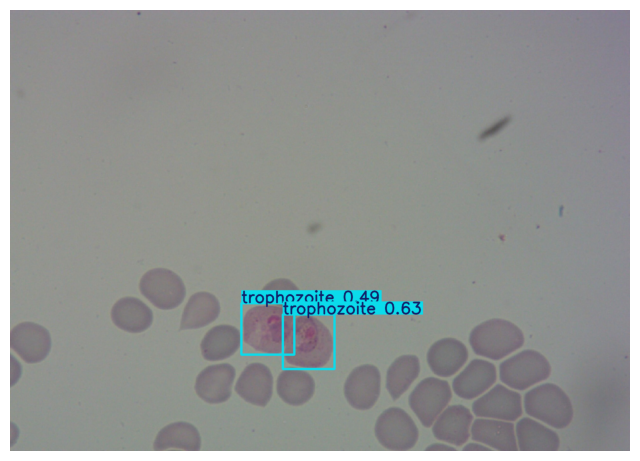

Saved → 1_annotated.jpg


In [7]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Load your trained model
model = YOLO("malaria_yolo11/train3/weights/best.pt")

# 2. Path to the image you want to test
img_path = "testim.jpg"

# 3. Run inference
results = model(img_path)

# 4. Annotated image (numpy array)
annotated = results[0].plot()

# 5. Show in Jupyter / Python
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# 6. Save without overwriting original
out_path = "1_annotated.jpg"
cv2.imwrite(out_path, annotated)

print("Saved →", out_path)
